In [1]:
# ============================================================
# CELL 1 — Setup, imports, paths, device check
# Notebook: 02_fidtm_finetuning_fdst.ipynb
# ============================================================

import os
import sys
import json
import random
import math
import time
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Paths
# -----------------------------
FIDTM_REPO_DIR = Path("/kaggle/working/repos/FIDTM")

FDST_ROOT = Path("/kaggle/input/datasets/yahiaelgayar/fdst-dataset/FDST")
FDST_IMAGES_DIR = FDST_ROOT / "images"
FDST_JSONS_DIR = FDST_ROOT / "jsons"

FIDTM_JHU_CKPT = Path("/kaggle/input/datasets/yahiaelgayar/fidtm-model/model_best_jhu (1).pth")

OUT_DIR = Path("/kaggle/working/fidtm_fdst_finetune")
CKPT_DIR = OUT_DIR / "checkpoints"
PLOT_DIR = OUT_DIR / "plots"
LOG_DIR = OUT_DIR / "logs"

for d in [OUT_DIR, CKPT_DIR, PLOT_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Print checks
# -----------------------------
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("\nFIDTM repo:", FIDTM_REPO_DIR, FIDTM_REPO_DIR.exists())
print("FDST root:", FDST_ROOT, FDST_ROOT.exists())
print("FDST images:", FDST_IMAGES_DIR, FDST_IMAGES_DIR.exists())
print("FDST jsons:", FDST_JSONS_DIR, FDST_JSONS_DIR.exists())
print("FIDTM checkpoint:", FIDTM_JHU_CKPT, FIDTM_JHU_CKPT.exists())

print("\nOutput dir:", OUT_DIR)
print("Checkpoint dir:", CKPT_DIR)
print("Plot dir:", PLOT_DIR)
print("Log dir:", LOG_DIR)

Device: cuda
GPU: Tesla T4

FIDTM repo: /kaggle/working/repos/FIDTM False
FDST root: /kaggle/input/datasets/yahiaelgayar/fdst-dataset/FDST True
FDST images: /kaggle/input/datasets/yahiaelgayar/fdst-dataset/FDST/images True
FDST jsons: /kaggle/input/datasets/yahiaelgayar/fdst-dataset/FDST/jsons True
FIDTM checkpoint: /kaggle/input/datasets/yahiaelgayar/fidtm-model/model_best_jhu (1).pth True

Output dir: /kaggle/working/fidtm_fdst_finetune
Checkpoint dir: /kaggle/working/fidtm_fdst_finetune/checkpoints
Plot dir: /kaggle/working/fidtm_fdst_finetune/plots
Log dir: /kaggle/working/fidtm_fdst_finetune/logs


In [2]:
# ============================================================
# CELL 2 — Enable GPU check + clone FIDTM repo
# ============================================================

import os
import sys
from pathlib import Path
import subprocess
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

if not torch.cuda.is_available():
    raise RuntimeError("GPU is not enabled. Go to Kaggle Settings > Accelerator > GPU, then restart session.")

print("GPU:", torch.cuda.get_device_name(0))

REPOS_DIR = Path("/kaggle/working/repos")
FIDTM_REPO_DIR = REPOS_DIR / "FIDTM"

REPOS_DIR.mkdir(parents=True, exist_ok=True)

if not FIDTM_REPO_DIR.exists():
    !git clone https://github.com/dk-liang/FIDTM.git /kaggle/working/repos/FIDTM
else:
    print("FIDTM repo already exists:", FIDTM_REPO_DIR)

print("FIDTM repo exists:", FIDTM_REPO_DIR.exists())
print("Files:", os.listdir(FIDTM_REPO_DIR)[:20])

Device: cuda
GPU: Tesla T4
Cloning into '/kaggle/working/repos/FIDTM'...
remote: Enumerating objects: 267, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 267 (delta 26), reused 40 (delta 16), pack-reused 212 (from 1)
Receiving objects: 100% (267/267), 25.66 MiB | 31.24 MiB/s, done.
Resolving deltas: 100% (123/123), done.
FIDTM repo exists: True
Files: ['.DS_Store', 'README.md', 'image.py', 'image', 'test.py', 'config.py', 'dataset.py', 'data', 'train_baseline.py', 'make_npydata.py', '.git', 'Networks', 'utils.py', 'video_demo.py', 'local_eval', 'LICENSE']


In [3]:
# ============================================================
# CELL 3 — Inspect FDST dataset and create train/val split
# ============================================================

from pathlib import Path
import json
import random
import pandas as pd

FDST_ROOT = Path("/kaggle/input/datasets/yahiaelgayar/fdst-dataset/FDST")
FDST_IMAGES_DIR = FDST_ROOT / "images"
FDST_JSONS_DIR = FDST_ROOT / "jsons"

OUT_DIR = Path("/kaggle/working/fidtm_fdst_finetune")
LOG_DIR = OUT_DIR / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)

# Collect image files
image_exts = ["*.jpg", "*.jpeg", "*.png", "*.bmp"]
image_files = []
for ext in image_exts:
    image_files.extend(list(FDST_IMAGES_DIR.rglob(ext)))

image_files = sorted(image_files)

# Collect json files
json_files = sorted(FDST_JSONS_DIR.rglob("*.json"))

print("Total images:", len(image_files))
print("Total jsons:", len(json_files))

print("\nSample images:")
for p in image_files[:10]:
    print(p)

print("\nSample jsons:")
for p in json_files[:10]:
    print(p)

# ------------------------------------------------------------
# Match images with json labels by relative stem/name strategy
# ------------------------------------------------------------
json_map = {p.stem: p for p in json_files}

samples = []

for img_path in image_files:
    stem = img_path.stem
    
    if stem in json_map:
        json_path = json_map[stem]
        samples.append({
            "image_path": str(img_path),
            "json_path": str(json_path),
            "stem": stem
        })

print("\nMatched samples:", len(samples))

if len(samples) == 0:
    raise RuntimeError("No image/json pairs matched. Need to inspect FDST file naming.")

# ------------------------------------------------------------
# Shuffle and split
# ------------------------------------------------------------
random.seed(42)
random.shuffle(samples)

val_ratio = 0.15
val_size = int(len(samples) * val_ratio)

val_samples = samples[:val_size]
train_samples = samples[val_size:]

train_df = pd.DataFrame(train_samples)
val_df = pd.DataFrame(val_samples)

train_csv = LOG_DIR / "fdst_train_split.csv"
val_csv = LOG_DIR / "fdst_val_split.csv"

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)

print("\nTrain samples:", len(train_df))
print("Val samples:", len(val_df))

print("\nSaved:")
print(train_csv)
print(val_csv)

print("\nTrain preview:")
display(train_df.head())

print("\nVal preview:")
display(val_df.head())

Total images: 15000
Total jsons: 15000

Sample images:
/kaggle/input/datasets/yahiaelgayar/fdst-dataset/FDST/images/100_001.jpg
/kaggle/input/datasets/yahiaelgayar/fdst-dataset/FDST/images/100_002.jpg
/kaggle/input/datasets/yahiaelgayar/fdst-dataset/FDST/images/100_003.jpg
/kaggle/input/datasets/yahiaelgayar/fdst-dataset/FDST/images/100_004.jpg
/kaggle/input/datasets/yahiaelgayar/fdst-dataset/FDST/images/100_005.jpg
/kaggle/input/datasets/yahiaelgayar/fdst-dataset/FDST/images/100_006.jpg
/kaggle/input/datasets/yahiaelgayar/fdst-dataset/FDST/images/100_007.jpg
/kaggle/input/datasets/yahiaelgayar/fdst-dataset/FDST/images/100_008.jpg
/kaggle/input/datasets/yahiaelgayar/fdst-dataset/FDST/images/100_009.jpg
/kaggle/input/datasets/yahiaelgayar/fdst-dataset/FDST/images/100_010.jpg

Sample jsons:
/kaggle/input/datasets/yahiaelgayar/fdst-dataset/FDST/jsons/100_001.json
/kaggle/input/datasets/yahiaelgayar/fdst-dataset/FDST/jsons/100_002.json
/kaggle/input/datasets/yahiaelgayar/fdst-dataset/FDST/

,image_path,json_path,stem
0,/kaggle/input/datasets/yahiaelgayar/fdst-datas...,/kaggle/input/datasets/yahiaelgayar/fdst-datas...,97_066
1,/kaggle/input/datasets/yahiaelgayar/fdst-datas...,/kaggle/input/datasets/yahiaelgayar/fdst-datas...,71_004
2,/kaggle/input/datasets/yahiaelgayar/fdst-datas...,/kaggle/input/datasets/yahiaelgayar/fdst-datas...,52_065
3,/kaggle/input/datasets/yahiaelgayar/fdst-datas...,/kaggle/input/datasets/yahiaelgayar/fdst-datas...,84_060
4,/kaggle/input/datasets/yahiaelgayar/fdst-datas...,/kaggle/input/datasets/yahiaelgayar/fdst-datas...,21_105



Val preview:


,image_path,json_path,stem
0,/kaggle/input/datasets/yahiaelgayar/fdst-datas...,/kaggle/input/datasets/yahiaelgayar/fdst-datas...,92_132
1,/kaggle/input/datasets/yahiaelgayar/fdst-datas...,/kaggle/input/datasets/yahiaelgayar/fdst-datas...,87_109
2,/kaggle/input/datasets/yahiaelgayar/fdst-datas...,/kaggle/input/datasets/yahiaelgayar/fdst-datas...,27_050
3,/kaggle/input/datasets/yahiaelgayar/fdst-datas...,/kaggle/input/datasets/yahiaelgayar/fdst-datas...,82_130
4,/kaggle/input/datasets/yahiaelgayar/fdst-datas...,/kaggle/input/datasets/yahiaelgayar/fdst-datas...,36_141


In [4]:
# ============================================================
# CELL 4 — Inspect FDST JSON annotation format
# ============================================================

import json
from pathlib import Path
import pandas as pd

sample_json = Path(val_df.iloc[0]["json_path"])

print("Sample JSON:", sample_json)

with open(sample_json, "r") as f:
    data = json.load(f)

print("\nJSON type:", type(data))

if isinstance(data, dict):
    print("Keys:", data.keys())
    for k, v in data.items():
        print("\nKEY:", k)
        print("TYPE:", type(v))
        if isinstance(v, list):
            print("LEN:", len(v))
            print("FIRST 5:", v[:5])
        else:
            print("VALUE:", v)

elif isinstance(data, list):
    print("List length:", len(data))
    print("First 10 items:", data[:10])
else:
    print(data)

Sample JSON: /kaggle/input/datasets/yahiaelgayar/fdst-dataset/FDST/jsons/92_132.json

JSON type: <class 'dict'>
Keys: dict_keys(['img_id', 'human_num', 'points', 'boxes'])

KEY: img_id
TYPE: <class 'str'>
VALUE: 132.jpg

KEY: human_num
TYPE: <class 'int'>
VALUE: 34

KEY: points
TYPE: <class 'list'>
LEN: 34
FIRST 5: [[754, 635], [1072, 775], [658, 677], [1183, 541], [586, 588]]

KEY: boxes
TYPE: <class 'list'>
LEN: 34
FIRST 5: [[741, 620, 768, 650], [1056, 759, 1089, 792], [645, 663, 672, 691], [1173, 529, 1193, 553], [576, 574, 596, 602]]


Train dataset: 12750
Val dataset: 2250
Image tensor: torch.Size([3, 512, 512]) torch.float32
Points: torch.Size([25, 2])
Count: 25.0
Original size: [1080.0, 1920.0]
Image path: /kaggle/input/datasets/yahiaelgayar/fdst-dataset/FDST/images/97_066.jpg


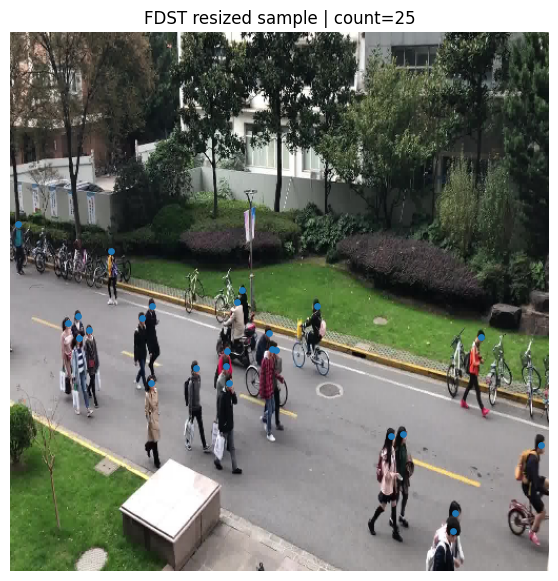

In [5]:
# ============================================================
# CELL 5 — FDST Dataset class + annotation visual check
# ============================================================

import cv2
import json
import numpy as np
import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt

class FDSTPointDataset(Dataset):
    def __init__(self, df, input_size=512, augment=False):
        self.df = df.reset_index(drop=True)
        self.input_size = input_size
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def _load_points(self, json_path):
        with open(json_path, "r") as f:
            ann = json.load(f)

        points = np.array(ann["points"], dtype=np.float32)

        if points.ndim == 1:
            points = points.reshape(-1, 2)

        return points

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = row["image_path"]
        json_path = row["json_path"]

        img = cv2.imread(img_path)
        if img is None:
            raise RuntimeError(f"Could not read image: {img_path}")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w = img.shape[:2]
        points = self._load_points(json_path)

        # Resize image to square input_size
        img_resized = cv2.resize(img, (self.input_size, self.input_size))

        sx = self.input_size / w
        sy = self.input_size / h

        points_resized = points.copy()
        points_resized[:, 0] *= sx
        points_resized[:, 1] *= sy

        # Normalize image
        img_tensor = torch.from_numpy(img_resized).permute(2, 0, 1).float() / 255.0

        sample = {
            "image": img_tensor,
            "points": torch.from_numpy(points_resized).float(),
            "count": torch.tensor(len(points_resized), dtype=torch.float32),
            "orig_size": torch.tensor([h, w], dtype=torch.float32),
            "image_path": img_path,
            "json_path": json_path,
        }

        return sample


train_dataset = FDSTPointDataset(train_df, input_size=512, augment=True)
val_dataset = FDSTPointDataset(val_df, input_size=512, augment=False)

print("Train dataset:", len(train_dataset))
print("Val dataset:", len(val_dataset))

sample = train_dataset[0]

print("Image tensor:", sample["image"].shape, sample["image"].dtype)
print("Points:", sample["points"].shape)
print("Count:", sample["count"].item())
print("Original size:", sample["orig_size"].tolist())
print("Image path:", sample["image_path"])

# Visual sanity check
img_np = sample["image"].permute(1, 2, 0).numpy()
pts = sample["points"].numpy()

plt.figure(figsize=(7, 7))
plt.imshow(img_np)
plt.scatter(pts[:, 0], pts[:, 1], s=15)
plt.title(f"FDST resized sample | count={len(pts)}")
plt.axis("off")
plt.show()

In [6]:
# ============================================================
# CELL 6 — Inspect FIDTM repo model files
# ============================================================

import os
from pathlib import Path

FIDTM_REPO_DIR = Path("/kaggle/working/repos/FIDTM")

print("Repo exists:", FIDTM_REPO_DIR.exists())

print("\nTop-level files:")
for p in sorted(FIDTM_REPO_DIR.iterdir()):
    print("-", p.name)

print("\nNetworks folder:")
net_dir = FIDTM_REPO_DIR / "Networks"
for root, dirs, files in os.walk(net_dir):
    level = root.replace(str(net_dir), "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{Path(root).name}/")
    for f in files[:20]:
        print(f"{indent}  {f}")

Repo exists: True

Top-level files:
- .DS_Store
- .git
- LICENSE
- Networks
- README.md
- config.py
- data
- dataset.py
- image
- image.py
- local_eval
- make_npydata.py
- test.py
- train_baseline.py
- utils.py
- video_demo.py

Networks folder:
Networks/
  HR_Net/
    models.py
    config.py
    __init__.py
    default.py
    seg_hrnet_w48.yaml
    seg_hrnet.py


In [8]:
# ============================================================
# CELL 7A — Inspect HRNet config files
# ============================================================

from pathlib import Path

FIDTM_REPO_DIR = Path("/kaggle/working/repos/FIDTM")

for file_name in ["config.py", "default.py", "models.py", "seg_hrnet.py"]:
    p = FIDTM_REPO_DIR / "Networks" / "HR_Net" / file_name
    print("\n" + "="*80)
    print(file_name)
    print("="*80)
    txt = p.read_text(errors="ignore").splitlines()
    for i, line in enumerate(txt[:120], start=1):
        print(f"{i:03d}: {line}")


config.py
001: import os
002: from easydict import EasyDict as edict
003: import time
004: import torch
005: 
006: # init
007: __C = edict()
008: cfg = __C
009: 
010: #------------------------------TRAIN------------------------
011: __C.SEED = 1  # random seed,  for reproduction
012: 
013: 
014: __C.NET = 'HR_Net'
015: __C.PRE_HR_WEIGHTS = '/home/dkliang/projects/synchronous/rdt_threshold/Networks/HR_Net/hrnetv2_w48_imagenet_pretrained.pth'

default.py
001: # ------------------------------------------------------------------------------
002: # Copyright (c) Microsoft
003: # Licensed under the MIT License.
004: # Written by Ke Sun (sunk@mail.ustc.edu.cn)
005: # ------------------------------------------------------------------------------
006: 
007: from __future__ import absolute_import
008: from __future__ import division
009: from __future__ import print_function
010: 
011: import os
012: 
013: from yacs.config import CfgNode as CN
014: 
015: _C = CN()
016: 
017: # common params for

In [10]:
# ============================================================
# CELL 7C — Install missing FIDTM dependency
# ============================================================

!pip install -q yacs easydict

import yacs
import easydict

print("yacs installed")
print("easydict installed")

yacs installed
easydict installed


In [11]:
# ============================================================
# CELL 7B — Correct FIDTM model loading
# ============================================================

import sys
import torch
from pathlib import Path

FIDTM_REPO_DIR = Path("/kaggle/working/repos/FIDTM")
FIDTM_JHU_CKPT = Path("/kaggle/input/datasets/yahiaelgayar/fidtm-model/model_best_jhu (1).pth")

sys.path.insert(0, str(FIDTM_REPO_DIR))

from Networks.HR_Net.seg_hrnet import get_seg_model
from Networks.HR_Net.default import _C, update_config
from Networks.HR_Net.models import MODEL_EXTRAS

yaml_path = FIDTM_REPO_DIR / "Networks/HR_Net/seg_hrnet_w48.yaml"

cfg = _C.clone()

# Fake args because update_config(args) expects path string
update_config(cfg, str(yaml_path))

cfg.defrost()
cfg.MODEL.EXTRA = MODEL_EXTRAS['seg_hrnet']
cfg.freeze()

print("Config loaded")

model = get_seg_model(cfg).to(DEVICE)

print("Model created")

ckpt = torch.load(FIDTM_JHU_CKPT, map_location=DEVICE)

print("Checkpoint type:", type(ckpt))

if isinstance(ckpt, dict):
    print("Keys:", list(ckpt.keys())[:20])

if isinstance(ckpt, dict) and "state_dict" in ckpt:
    state_dict = ckpt["state_dict"]

elif isinstance(ckpt, dict) and "model" in ckpt:
    state_dict = ckpt["model"]

else:
    state_dict = ckpt

clean_dict = {}

for k,v in state_dict.items():
    clean_key = k.replace("module.","")
    clean_dict[clean_key]=v

missing,unexpected = model.load_state_dict(
    clean_dict,
    strict=False
)

print("\nLoaded.")
print("Missing:",len(missing))
print("Unexpected:",len(unexpected))

model.eval()

x=torch.randn(1,3,512,512).to(DEVICE)

with torch.no_grad():

    y=model(x)

print("\nOutput type:",type(y))

if isinstance(y,(list,tuple)):
    print("Num outputs:",len(y))

    for i,o in enumerate(y):
        print(i,o.shape)

else:

    print("Shape:",y.shape)

Config loaded


FileNotFoundError: [Errno 2] No such file or directory: './Networks/HR_Net/seg_hrnet_w48.yaml'

In [13]:
# ============================================================
# CELL 7E — Patch NumPy compatibility and load FIDTM
# ============================================================

import os
import sys
import torch
import numpy as np
from pathlib import Path

# Patch old FIDTM code using np.int
np.int = int

FIDTM_REPO_DIR = Path("/kaggle/working/repos/FIDTM")
FIDTM_JHU_CKPT = Path("/kaggle/input/datasets/yahiaelgayar/fidtm-model/model_best_jhu (1).pth")

os.chdir(FIDTM_REPO_DIR)
sys.path.insert(0, str(FIDTM_REPO_DIR))

from Networks.HR_Net.seg_hrnet import get_seg_model

model = get_seg_model().to(DEVICE)

print("Model created")

ckpt = torch.load(FIDTM_JHU_CKPT, map_location=DEVICE)

if isinstance(ckpt, dict) and "state_dict" in ckpt:
    state_dict = ckpt["state_dict"]
elif isinstance(ckpt, dict) and "model" in ckpt:
    state_dict = ckpt["model"]
else:
    state_dict = ckpt

clean_dict = {}
for k, v in state_dict.items():
    clean_dict[k.replace("module.", "")] = v

missing, unexpected = model.load_state_dict(clean_dict, strict=False)

print("Checkpoint loaded")
print("Missing keys:", len(missing))
print("Unexpected keys:", len(unexpected))

if len(missing) > 0:
    print("First missing:", missing[:10])

if len(unexpected) > 0:
    print("First unexpected:", unexpected[:10])

model.eval()

x = torch.randn(1, 3, 512, 512).to(DEVICE)

with torch.no_grad():
    y = model(x)

print("Forward OK")
print("Output type:", type(y))

if isinstance(y, (tuple, list)):
    for i, o in enumerate(y):
        print(i, o.shape, o.min().item(), o.max().item())
else:
    print(y.shape, y.min().item(), y.max().item())

Model created
Checkpoint loaded
Missing keys: 0
Unexpected keys: 0
Forward OK
Output type: <class 'torch.Tensor'>
torch.Size([1, 1, 512, 512]) -0.002398863434791565 0.41942495107650757


/kaggle/working/repos/FIDTM/Networks/HR_Net/seg_hrnet.py:454: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x1 = F.upsample(x[1], size=(x0_h, x0_w), mode='bilinear')
/kaggle/working/repos/FIDTM/Networks/HR_Net/seg_hrnet.py:455: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x2 = F.upsample(x[2], size=(x0_h, x0_w), mode='bilinear')
/kaggle/working/repos/FIDTM/Networks/HR_Net/seg_hrnet.py:456: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x3 = F.upsample(x[3], size=(x0_h, x0_w), mode='bilinear')


Images: torch.Size([2, 3, 512, 512])
Targets: torch.Size([2, 1, 512, 512])
Counts: tensor([37., 21.])
Target sums: tensor([37., 21.])


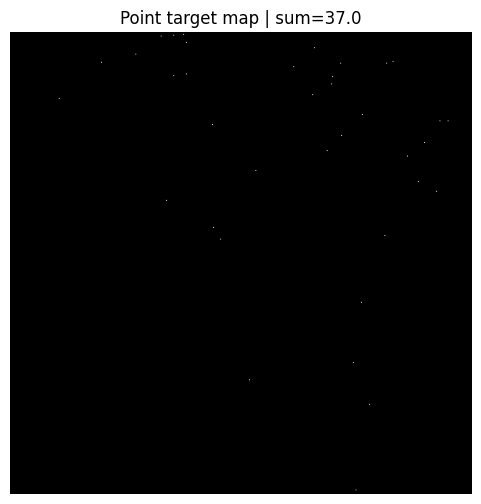

In [14]:
# ============================================================
# CELL 8 — Generate FIDTM training targets + DataLoader test
# ============================================================

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

def make_point_map(points, size=512):
    """
    Creates a 1-channel point map from head points.
    Each head point = 1 pixel.
    """
    target = torch.zeros((1, size, size), dtype=torch.float32)

    if points.numel() == 0:
        return target

    pts = points.clone()
    pts[:, 0] = torch.clamp(torch.round(pts[:, 0]), 0, size - 1)
    pts[:, 1] = torch.clamp(torch.round(pts[:, 1]), 0, size - 1)

    xs = pts[:, 0].long()
    ys = pts[:, 1].long()

    target[0, ys, xs] = 1.0
    return target


def fidtm_collate_fn(batch):
    images = torch.stack([b["image"] for b in batch], dim=0)
    counts = torch.stack([b["count"] for b in batch], dim=0)

    targets = torch.stack(
        [make_point_map(b["points"], size=512) for b in batch],
        dim=0
    )

    image_paths = [b["image_path"] for b in batch]
    json_paths = [b["json_path"] for b in batch]
    points = [b["points"] for b in batch]

    return {
        "images": images,
        "targets": targets,
        "counts": counts,
        "points": points,
        "image_paths": image_paths,
        "json_paths": json_paths,
    }


BATCH_SIZE = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=fidtm_collate_fn,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=fidtm_collate_fn,
    drop_last=False
)

batch = next(iter(train_loader))

print("Images:", batch["images"].shape)
print("Targets:", batch["targets"].shape)
print("Counts:", batch["counts"])
print("Target sums:", batch["targets"].sum(dim=(1,2,3)))

plt.figure(figsize=(6, 6))
plt.imshow(batch["targets"][0, 0].numpy(), cmap="gray")
plt.title(f"Point target map | sum={batch['targets'][0].sum().item()}")
plt.axis("off")
plt.show()

Images: torch.Size([2, 3, 512, 512])
Targets: torch.Size([2, 1, 512, 512])
GT counts: tensor([37., 22.])
Target sums: tensor([37., 22.])


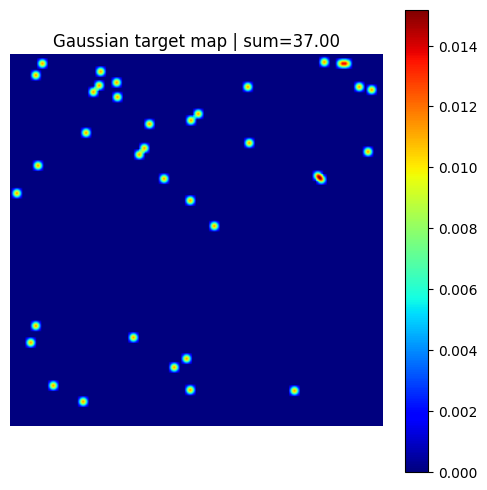

In [15]:
# ============================================================
# CELL 9 — Gaussian target maps for smoother FIDTM fine-tuning
# ============================================================

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def gaussian_kernel2d(kernel_size=15, sigma=4.0):
    ax = torch.arange(kernel_size).float() - kernel_size // 2
    xx, yy = torch.meshgrid(ax, ax, indexing="ij")
    kernel = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / kernel.sum()
    return kernel


GAUSS_KERNEL_SIZE = 15
GAUSS_SIGMA = 4.0

gauss_kernel = gaussian_kernel2d(GAUSS_KERNEL_SIZE, GAUSS_SIGMA)
gauss_kernel = gauss_kernel.view(1, 1, GAUSS_KERNEL_SIZE, GAUSS_KERNEL_SIZE)

def make_gaussian_map(points, size=512):
    point_map = make_point_map(points, size=size).unsqueeze(0)
    kernel = gauss_kernel.to(point_map.device)

    density = F.conv2d(
        point_map,
        kernel,
        padding=GAUSS_KERNEL_SIZE // 2
    )

    density = density.squeeze(0)

    # preserve count after smoothing
    original_count = point_map.sum()
    new_sum = density.sum()

    if new_sum > 0:
        density = density * (original_count / new_sum)

    return density


def fidtm_collate_fn(batch):
    images = torch.stack([b["image"] for b in batch], dim=0)
    counts = torch.stack([b["count"] for b in batch], dim=0)

    targets = torch.stack(
        [make_gaussian_map(b["points"], size=512) for b in batch],
        dim=0
    )

    return {
        "images": images,
        "targets": targets,
        "counts": counts,
        "points": [b["points"] for b in batch],
        "image_paths": [b["image_path"] for b in batch],
        "json_paths": [b["json_path"] for b in batch],
    }


train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=fidtm_collate_fn,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=fidtm_collate_fn,
    drop_last=False
)

batch = next(iter(train_loader))

print("Images:", batch["images"].shape)
print("Targets:", batch["targets"].shape)
print("GT counts:", batch["counts"])
print("Target sums:", batch["targets"].sum(dim=(1,2,3)))

plt.figure(figsize=(6, 6))
plt.imshow(batch["targets"][0, 0].numpy(), cmap="jet")
plt.title(f"Gaussian target map | sum={batch['targets'][0].sum().item():.2f}")
plt.axis("off")
plt.colorbar()
plt.show()

In [16]:
# ============================================================
# CELL 10 — Evaluation helpers: peak detection, MAE, RMSE, F1
# ============================================================

import numpy as np
import torch
import torch.nn.functional as F
from scipy.spatial.distance import cdist

PEAK_THRESHOLD = 0.20
NMS_KERNEL = 3
MATCH_DISTANCE = 16

def extract_peaks(pred_map, threshold=PEAK_THRESHOLD, nms_kernel=NMS_KERNEL):
    """
    pred_map: torch Tensor [H,W] or numpy [H,W]
    returns numpy points: [N,2] in x,y
    """
    if isinstance(pred_map, np.ndarray):
        x = torch.from_numpy(pred_map).float()
    else:
        x = pred_map.detach().float().cpu()

    if x.ndim == 3:
        x = x.squeeze(0)

    x4 = x.unsqueeze(0).unsqueeze(0)

    pooled = F.max_pool2d(
        x4,
        kernel_size=nms_kernel,
        stride=1,
        padding=nms_kernel // 2
    )

    keep = (x4 == pooled) & (x4 >= threshold)
    ys, xs = torch.where(keep[0, 0])

    if len(xs) == 0:
        return np.zeros((0, 2), dtype=np.float32)

    pts = torch.stack([xs, ys], dim=1).cpu().numpy().astype(np.float32)
    return pts


def localization_metrics(pred_points, gt_points, match_distance=MATCH_DISTANCE):
    """
    pred_points and gt_points: numpy arrays [N,2], x,y
    """
    if len(pred_points) == 0 and len(gt_points) == 0:
        return 1.0, 1.0, 1.0, 0, 0, 0

    if len(pred_points) == 0:
        tp = 0
        fp = 0
        fn = len(gt_points)
        return 0.0, 0.0, 0.0, tp, fp, fn

    if len(gt_points) == 0:
        tp = 0
        fp = len(pred_points)
        fn = 0
        return 0.0, 0.0, 0.0, tp, fp, fn

    dist = cdist(pred_points, gt_points)

    matched_pred = set()
    matched_gt = set()

    while True:
        min_idx = np.unravel_index(np.argmin(dist), dist.shape)
        min_dist = dist[min_idx]

        if min_dist > match_distance:
            break

        p_idx, g_idx = min_idx

        if p_idx not in matched_pred and g_idx not in matched_gt:
            matched_pred.add(p_idx)
            matched_gt.add(g_idx)

        dist[p_idx, :] = np.inf
        dist[:, g_idx] = np.inf

        if not np.isfinite(dist).any():
            break

    tp = len(matched_pred)
    fp = len(pred_points) - tp
    fn = len(gt_points) - tp

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return precision, recall, f1, tp, fp, fn


@torch.no_grad()
def evaluate_model(model, loader, max_batches=None):
    model.eval()

    abs_errors = []
    sq_errors = []

    total_tp = 0
    total_fp = 0
    total_fn = 0

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        images = batch["images"].to(DEVICE)

        outputs = model(images)

        outputs = torch.clamp(outputs, min=0)

        for i in range(outputs.shape[0]):
            pred_map = outputs[i, 0].detach().cpu()
            gt_count = batch["counts"][i].item()

            pred_count = pred_map.sum().item()

            abs_errors.append(abs(pred_count - gt_count))
            sq_errors.append((pred_count - gt_count) ** 2)

            pred_pts = extract_peaks(pred_map)

            gt_pts = batch["points"][i].cpu().numpy()

            _, _, _, tp, fp, fn = localization_metrics(pred_pts, gt_pts)

            total_tp += tp
            total_fp += fp
            total_fn += fn

    mae = float(np.mean(abs_errors))
    rmse = float(np.sqrt(np.mean(sq_errors)))

    precision = total_tp / (total_tp + total_fp + 1e-8)
    recall = total_tp / (total_tp + total_fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "precision": precision,
        "recall": recall,
        "F1": f1,
        "TP": total_tp,
        "FP": total_fp,
        "FN": total_fn,
    }


# Quick validation subset test
quick_metrics = evaluate_model(model, val_loader, max_batches=20)

print("Quick pretrained validation test on 20 frames:")
for k, v in quick_metrics.items():
    print(k, ":", v)

/kaggle/working/repos/FIDTM/Networks/HR_Net/seg_hrnet.py:454: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x1 = F.upsample(x[1], size=(x0_h, x0_w), mode='bilinear')
/kaggle/working/repos/FIDTM/Networks/HR_Net/seg_hrnet.py:455: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x2 = F.upsample(x[2], size=(x0_h, x0_w), mode='bilinear')
/kaggle/working/repos/FIDTM/Networks/HR_Net/seg_hrnet.py:456: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x3 = F.upsample(x[3], size=(x0_h, x0_w), mode='bilinear')


Quick pretrained validation test on 20 frames:
MAE : 3341.5300994873046
RMSE : 4087.828926834691
precision : 0.6464646464483216
recall : 0.5676274944441768
F1 : 0.6044864176750501
TP : 256
FP : 140
FN : 195


In [17]:
# ============================================================
# CELL 11 — Calibrate FIDTM output scale for count evaluation
# ============================================================

@torch.no_grad()
def estimate_count_scale(model, loader, max_batches=100):
    model.eval()

    raw_sums = []
    gt_counts = []

    for bi, batch in enumerate(loader):
        if bi >= max_batches:
            break

        images = batch["images"].to(DEVICE)
        outputs = torch.clamp(model(images), min=0)

        for i in range(outputs.shape[0]):
            raw_sums.append(outputs[i, 0].sum().item())
            gt_counts.append(batch["counts"][i].item())

    raw_sums = np.array(raw_sums)
    gt_counts = np.array(gt_counts)

    scale = gt_counts.sum() / (raw_sums.sum() + 1e-8)

    return scale, raw_sums, gt_counts


COUNT_SCALE, raw_sums, gt_counts = estimate_count_scale(model, val_loader, max_batches=100)

print("Estimated COUNT_SCALE:", COUNT_SCALE)
print("Raw pred sum mean:", raw_sums.mean())
print("GT count mean:", gt_counts.mean())

print("\nFirst 10 raw sums vs GT:")
for i in range(min(10, len(raw_sums))):
    print(f"raw={raw_sums[i]:.2f} | scaled={raw_sums[i]*COUNT_SCALE:.2f} | gt={gt_counts[i]:.0f}")

Estimated COUNT_SCALE: 0.008426278204210352
Raw pred sum mean: 2919.4383811950684
GT count mean: 24.6

First 10 raw sums vs GT:
raw=6298.31 | scaled=53.07 | gt=34
raw=1543.73 | scaled=13.01 | gt=24
raw=6043.51 | scaled=50.92 | gt=21
raw=2380.23 | scaled=20.06 | gt=23
raw=1376.29 | scaled=11.60 | gt=18
raw=1940.04 | scaled=16.35 | gt=23
raw=6091.26 | scaled=51.33 | gt=21
raw=585.60 | scaled=4.93 | gt=11
raw=1110.08 | scaled=9.35 | gt=20
raw=7473.51 | scaled=62.97 | gt=23


In [18]:
# ============================================================
# CELL 12 — Corrected evaluation using COUNT_SCALE for counts
# ============================================================

@torch.no_grad()
def evaluate_model_scaled(model, loader, count_scale=1.0, max_batches=None):
    model.eval()

    abs_errors = []
    sq_errors = []

    total_tp = 0
    total_fp = 0
    total_fn = 0

    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        images = batch["images"].to(DEVICE)
        outputs = torch.clamp(model(images), min=0)

        for i in range(outputs.shape[0]):
            pred_map = outputs[i, 0].detach().cpu()
            gt_count = batch["counts"][i].item()

            pred_count = pred_map.sum().item() * count_scale

            abs_errors.append(abs(pred_count - gt_count))
            sq_errors.append((pred_count - gt_count) ** 2)

            pred_pts = extract_peaks(pred_map)
            gt_pts = batch["points"][i].cpu().numpy()

            _, _, _, tp, fp, fn = localization_metrics(pred_pts, gt_pts)

            total_tp += tp
            total_fp += fp
            total_fn += fn

    mae = float(np.mean(abs_errors))
    rmse = float(np.sqrt(np.mean(sq_errors)))

    precision = total_tp / (total_tp + total_fp + 1e-8)
    recall = total_tp / (total_tp + total_fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "precision": precision,
        "recall": recall,
        "F1": f1,
        "TP": total_tp,
        "FP": total_fp,
        "FN": total_fn,
    }


pretrained_quick_metrics = evaluate_model_scaled(
    model,
    val_loader,
    count_scale=COUNT_SCALE,
    max_batches=100
)

print("Pretrained FIDTM validation test on 100 frames:")
for k, v in pretrained_quick_metrics.items():
    print(k, ":", v)

Pretrained FIDTM validation test on 100 frames:
MAE : 10.55319314149349
RMSE : 14.658609718306744
precision : 0.7115097159904759
recall : 0.5804878048756891
F1 : 0.6393552670431851
TP : 1428
FP : 579
FN : 1032


GT count: 34.0
Raw pred sum: 6298.30908203125
Scaled pred count: 53.07130454130004
Predicted peaks: 42


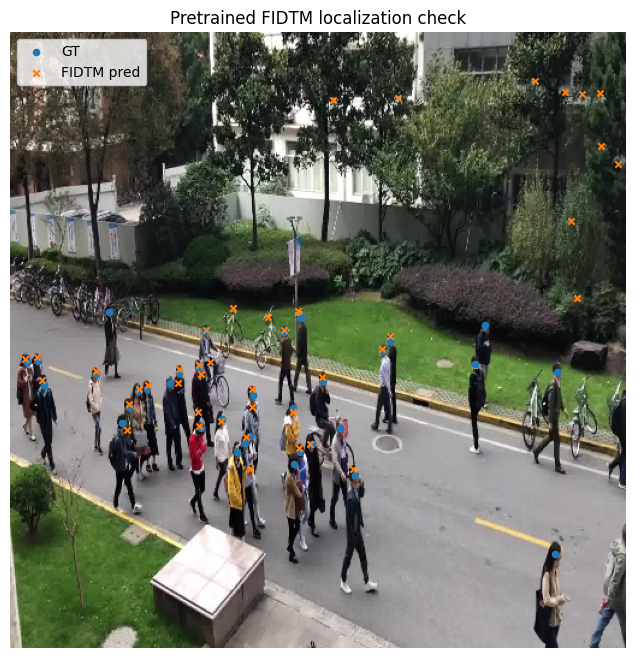

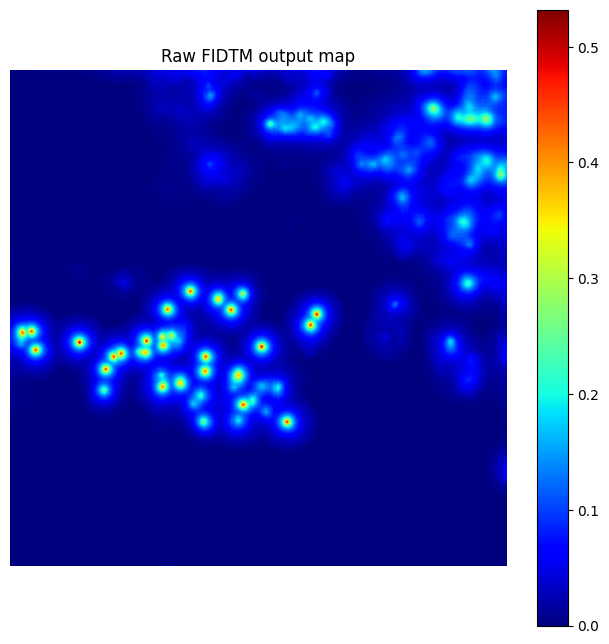

In [19]:
# ============================================================
# CELL 13 — Visual check pretrained FIDTM output on FDST image
# ============================================================

model.eval()

sample = val_dataset[0]
img = sample["image"].unsqueeze(0).to(DEVICE)
gt_pts = sample["points"].numpy()
gt_count = sample["count"].item()

with torch.no_grad():
    pred = torch.clamp(model(img), min=0)[0, 0].detach().cpu()

pred_pts = extract_peaks(pred, threshold=0.20)

print("GT count:", gt_count)
print("Raw pred sum:", pred.sum().item())
print("Scaled pred count:", pred.sum().item() * COUNT_SCALE)
print("Predicted peaks:", len(pred_pts))

img_np = sample["image"].permute(1, 2, 0).numpy()

plt.figure(figsize=(8, 8))
plt.imshow(img_np)
plt.scatter(gt_pts[:, 0], gt_pts[:, 1], s=20, label="GT")
if len(pred_pts) > 0:
    plt.scatter(pred_pts[:, 0], pred_pts[:, 1], s=20, marker="x", label="FIDTM pred")
plt.legend()
plt.title("Pretrained FIDTM localization check")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(pred.numpy(), cmap="jet")
plt.title("Raw FIDTM output map")
plt.axis("off")
plt.colorbar()
plt.show()

In [20]:
# ============================================================
# CELL 14 — Search best peak threshold on validation subset
# ============================================================

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

rows = []

for th in thresholds:
    PEAK_THRESHOLD = th
    
    def extract_peaks_temp(pred_map, threshold=th, nms_kernel=3):
        x = pred_map.detach().float().cpu()
        if x.ndim == 3:
            x = x.squeeze(0)

        x4 = x.unsqueeze(0).unsqueeze(0)
        pooled = F.max_pool2d(x4, kernel_size=nms_kernel, stride=1, padding=nms_kernel//2)
        keep = (x4 == pooled) & (x4 >= threshold)
        ys, xs = torch.where(keep[0, 0])

        if len(xs) == 0:
            return np.zeros((0, 2), dtype=np.float32)

        return torch.stack([xs, ys], dim=1).cpu().numpy().astype(np.float32)

    total_tp, total_fp, total_fn = 0, 0, 0
    abs_peak_errors = []

    model.eval()

    with torch.no_grad():
        for bi, batch in enumerate(val_loader):
            if bi >= 100:
                break

            images = batch["images"].to(DEVICE)
            outputs = torch.clamp(model(images), min=0)

            pred_map = outputs[0, 0].detach().cpu()
            pred_pts = extract_peaks_temp(pred_map, threshold=th)
            gt_pts = batch["points"][0].cpu().numpy()

            _, _, _, tp, fp, fn = localization_metrics(pred_pts, gt_pts)

            total_tp += tp
            total_fp += fp
            total_fn += fn
            abs_peak_errors.append(abs(len(pred_pts) - len(gt_pts)))

    precision = total_tp / (total_tp + total_fp + 1e-8)
    recall = total_tp / (total_tp + total_fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    peak_mae = np.mean(abs_peak_errors)

    rows.append({
        "threshold": th,
        "precision": precision,
        "recall": recall,
        "F1": f1,
        "peak_count_MAE": peak_mae,
        "TP": total_tp,
        "FP": total_fp,
        "FN": total_fn
    })

threshold_df = pd.DataFrame(rows)
display(threshold_df)

best_row = threshold_df.sort_values("F1", ascending=False).iloc[0]
BEST_PEAK_THRESHOLD = float(best_row["threshold"])

print("Best threshold:", BEST_PEAK_THRESHOLD)
print(best_row)

,threshold,precision,recall,F1,peak_count_MAE,TP,FP,FN
0,0.10,0.331490,0.682114,0.446158,29.36,1678,3384,782
1,0.15,0.543119,0.627236,0.582154,11.87,1543,1298,917
2,0.20,0.711510,0.580488,0.639355,7.75,1428,579,1032
3,0.25,0.814745,0.525610,0.638992,9.19,1293,294,1167
4,0.30,0.893077,0.471951,0.617553,11.62,1161,139,1299
5,0.35,0.933809,0.372764,0.532830,14.78,917,65,1543
6,0.40,0.961672,0.224390,0.363876,18.86,552,22,1908
7,0.50,0.976744,0.017073,0.033560,24.17,42,1,2418


Best threshold: 0.2
threshold            0.200000
precision            0.711510
recall               0.580488
F1                   0.639355
peak_count_MAE       7.750000
TP                1428.000000
FP                 579.000000
FN                1032.000000
Name: 2, dtype: float64


In [21]:
# ============================================================
# CELL 15 — Fine-tuning setup (freeze most layers)
# ============================================================

trainable = 0
frozen = 0

for name, param in model.named_parameters():

    # train only head / final layers first
    if (
        "last_layer" in name
        or "final" in name
        or "head" in name
    ):
        param.requires_grad = True
        trainable += param.numel()

    else:
        param.requires_grad = False
        frozen += param.numel()

print("Trainable params:", f"{trainable:,}")
print("Frozen params:", f"{frozen:,}")

import torch.optim as optim
import torch.nn as nn

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

criterion = nn.MSELoss()

EPOCHS = 20
SAVE_EVERY = 5

best_f1 = pretrained_quick_metrics["F1"]
best_mae = pretrained_quick_metrics["MAE"]

history = []

print("Initial best F1:", best_f1)
print("Initial best MAE:", best_mae)

Trainable params: 1,258,929
Frozen params: 65,325,120
Initial best F1: 0.6393552670431851
Initial best MAE: 10.55319314149349


In [22]:
# ============================================================
# CELL 16 — Fine-tuning loop with checkpointing and logs
# ============================================================

import time
import pandas as pd
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion, epoch):
    model.train()
    total_loss = 0.0
    n = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch}/{EPOCHS}")

    for batch in pbar:
        images = batch["images"].to(DEVICE, non_blocking=True)
        targets = batch["targets"].to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        if outputs.shape != targets.shape:
            outputs = F.interpolate(outputs, size=targets.shape[-2:], mode="bilinear", align_corners=False)

        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n += 1

        pbar.set_postfix(loss=f"{loss.item():.8f}")

    return total_loss / max(n, 1)


for epoch in range(1, EPOCHS + 1):
    start = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, epoch)

    # quick validation: 100 frames to keep runtime reasonable
    metrics = evaluate_model_scaled(
        model,
        val_loader,
        count_scale=COUNT_SCALE,
        max_batches=100
    )

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "F1": metrics["F1"],
        "time_min": (time.time() - start) / 60
    }

    history.append(row)

    print("\nEpoch result:")
    for k, v in row.items():
        print(k, ":", v)

    # save every 5 epochs
    if epoch % SAVE_EVERY == 0:
        ckpt_path = CKPT_DIR / f"fidtm_fdst_epoch_{epoch}.pth"
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "metrics": metrics,
            "count_scale": COUNT_SCALE,
            "best_f1": best_f1,
            "best_mae": best_mae
        }, ckpt_path)
        print("Saved checkpoint:", ckpt_path)

    # save best by F1
    if metrics["F1"] > best_f1:
        best_f1 = metrics["F1"]
        best_path = CKPT_DIR / "fidtm_fdst_best_f1.pth"
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "metrics": metrics,
            "count_scale": COUNT_SCALE,
            "best_f1": best_f1,
            "best_mae": best_mae
        }, best_path)
        print("Saved BEST F1:", best_path)

    # save best by MAE
    if metrics["MAE"] < best_mae:
        best_mae = metrics["MAE"]
        best_path = CKPT_DIR / "fidtm_fdst_best_mae.pth"
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "metrics": metrics,
            "count_scale": COUNT_SCALE,
            "best_f1": best_f1,
            "best_mae": best_mae
        }, best_path)
        print("Saved BEST MAE:", best_path)

    # save CSV log every epoch
    hist_df = pd.DataFrame(history)
    hist_csv = LOG_DIR / "fidtm_fdst_training_log.csv"
    hist_df.to_csv(hist_csv, index=False)
    print("Updated log:", hist_csv)

print("Training finished.")
print("Best F1:", best_f1)
print("Best MAE:", best_mae)

Epoch 1/20:   0%|          | 0/6375 [00:00<?, ?it/s]/kaggle/working/repos/FIDTM/Networks/HR_Net/seg_hrnet.py:454: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x1 = F.upsample(x[1], size=(x0_h, x0_w), mode='bilinear')
/kaggle/working/repos/FIDTM/Networks/HR_Net/seg_hrnet.py:455: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x2 = F.upsample(x[2], size=(x0_h, x0_w), mode='bilinear')
/kaggle/working/repos/FIDTM/Networks/HR_Net/seg_hrnet.py:456: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x3 = F.upsample(x[3], size=(x0_h, x0_w), mode='bilinear')
Epoch 1/20: 100%|██████████| 6375/6375 [20:48<00:00,  5.11it/s, loss=0.00000733]



Epoch result:
epoch : 1
train_loss : 9.95118341864095e-05
MAE : 18.815162497657116
RMSE : 21.430418590172206
precision : 0.00088118666470718
recall : 0.0024390243902339876
F1 : 0.0012946341415257573
time_min : 20.932947425047555
Updated log: /kaggle/working/fidtm_fdst_finetune/logs/fidtm_fdst_training_log.csv


Epoch 2/20:   3%|▎         | 197/6375 [00:38<20:07,  5.12it/s, loss=0.00000451]Exception in thread Thread-22 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 540, in rebuild_storage_fd
    fd = df.deta

KeyboardInterrupt: 

In [23]:
# ============================================================
# CELL 17 — Reload original pretrained checkpoint after collapse
# ============================================================

model = get_seg_model().to(DEVICE)

ckpt = torch.load(FIDTM_JHU_CKPT, map_location=DEVICE)

if isinstance(ckpt, dict) and "state_dict" in ckpt:
    state_dict = ckpt["state_dict"]
elif isinstance(ckpt, dict) and "model" in ckpt:
    state_dict = ckpt["model"]
else:
    state_dict = ckpt

clean_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

missing, unexpected = model.load_state_dict(clean_dict, strict=False)

print("Reloaded pretrained FIDTM")
print("Missing:", len(missing))
print("Unexpected:", len(unexpected))

model.eval()

metrics = evaluate_model_scaled(
    model,
    val_loader,
    count_scale=COUNT_SCALE,
    max_batches=100
)

print(metrics)

Reloaded pretrained FIDTM
Missing: 0
Unexpected: 0
{'MAE': 10.553193064348607, 'RMSE': 14.658609566216791, 'precision': 0.7115097159904759, 'recall': 0.5804878048756891, 'F1': 0.6393552670431851, 'TP': 1428, 'FP': 579, 'FN': 1032}


In [24]:
from pathlib import Path
import os, sys, json, time, random, subprocess
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
from PIL import Image
from tqdm.auto import tqdm
from scipy.io import loadmat
from scipy.optimize import linear_sum_assignment
from torchvision import transforms

WORK_DIR = Path("/kaggle/working")
INPUT_BASE = Path("/kaggle/input/datasets/yahiaelgayar")

FDST_ROOT = INPUT_BASE / "fdst-dataset" / "FDST"
FDST_IMAGES_DIR = FDST_ROOT / "images"
FDST_JSONS_DIR = FDST_ROOT / "jsons"

MALL_ROOT = INPUT_BASE / "mall-dataset" / "mall_dataset"
MALL_FRAMES_DIR = MALL_ROOT / "frames"
MALL_GT_MAT = MALL_ROOT / "mall_gt.mat"

FIDTM_WEIGHT_PATH = INPUT_BASE / "fidtm-model" / "model_best_jhu (1).pth"

BENCH_DIR = WORK_DIR / "benchmark_results"
BENCH_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MAX_FDST_FRAMES = 6000

print("Device:", DEVICE)
print("FDST:", FDST_ROOT.exists())
print("Mall:", MALL_ROOT.exists())
print("FIDTM weight:", FIDTM_WEIGHT_PATH.exists())

Device: cuda
FDST: True
Mall: True
FIDTM weight: True


In [25]:
REPOS_DIR = WORK_DIR / "repos"
REPOS_DIR.mkdir(exist_ok=True)

FIDTM_REPO = REPOS_DIR / "FIDTM"

if not FIDTM_REPO.exists():
    !git clone https://github.com/dk-liang/FIDTM.git /kaggle/working/repos/FIDTM

!pip install -q yacs

os.chdir(FIDTM_REPO)

if str(FIDTM_REPO) not in sys.path:
    sys.path.insert(0, str(FIDTM_REPO))

from Networks.HR_Net.seg_hrnet import get_seg_model

fidtm_model = get_seg_model()
fidtm_model = nn.DataParallel(fidtm_model)

ckpt = torch.load(FIDTM_WEIGHT_PATH, map_location="cpu")
missing, unexpected = fidtm_model.load_state_dict(ckpt["state_dict"], strict=False)

fidtm_model = fidtm_model.to(DEVICE)
fidtm_model.eval()

print("Reloaded pretrained FIDTM")
print("Missing:", len(missing))
print("Unexpected:", len(unexpected))

Reloaded pretrained FIDTM
Missing: 0
Unexpected: 0


In [26]:
def load_mall_samples(frames_dir: Path, gt_mat_path: Path) -> pd.DataFrame:
    mat = loadmat(gt_mat_path)
    counts = np.asarray(mat["count"]).reshape(-1)
    frame_paths = sorted(frames_dir.glob("*.jpg"))

    rows = []
    for i, frame_path in enumerate(frame_paths[:len(counts)]):
        rows.append({
            "dataset": "Mall",
            "frame_id": frame_path.stem,
            "image_path": str(frame_path),
            "gt_count": int(counts[i]),
        })
    return pd.DataFrame(rows)


def count_points_in_fdst_json(json_path: Path) -> int:
    with open(json_path, "r") as f:
        data = json.load(f)

    if isinstance(data, list):
        return len(data)

    if isinstance(data, dict):
        for key in ["points", "annotations", "annPoints", "gt_points", "locations"]:
            if key in data and isinstance(data[key], list):
                return len(data[key])

    raise ValueError(f"Unknown FDST JSON format: {json_path}")


def load_fdst_samples(images_dir: Path, jsons_dir: Path, max_frames: int = 6000) -> pd.DataFrame:
    image_paths = sorted(images_dir.glob("*.jpg"))[:max_frames]
    rows = []

    for img_path in image_paths:
        json_path = jsons_dir / f"{img_path.stem}.json"
        rows.append({
            "dataset": "FDST",
            "frame_id": img_path.stem,
            "image_path": str(img_path),
            "gt_count": count_points_in_fdst_json(json_path),
        })

    return pd.DataFrame(rows)


mall_df = load_mall_samples(MALL_FRAMES_DIR, MALL_GT_MAT)
fdst_df = load_fdst_samples(FDST_IMAGES_DIR, FDST_JSONS_DIR, MAX_FDST_FRAMES)

print("Mall:", len(mall_df))
print("FDST:", len(fdst_df))
print(mall_df.head())
print(fdst_df.head())

Mall: 2000
FDST: 6000
  dataset    frame_id                                         image_path  \
0    Mall  seq_000001  /kaggle/input/datasets/yahiaelgayar/mall-datas...   
1    Mall  seq_000002  /kaggle/input/datasets/yahiaelgayar/mall-datas...   
2    Mall  seq_000003  /kaggle/input/datasets/yahiaelgayar/mall-datas...   
3    Mall  seq_000004  /kaggle/input/datasets/yahiaelgayar/mall-datas...   
4    Mall  seq_000005  /kaggle/input/datasets/yahiaelgayar/mall-datas...   

   gt_count  
0        29  
1        30  
2        35  
3        31  
4        26  
  dataset frame_id                                         image_path  \
0    FDST  100_001  /kaggle/input/datasets/yahiaelgayar/fdst-datas...   
1    FDST  100_002  /kaggle/input/datasets/yahiaelgayar/fdst-datas...   
2    FDST  100_003  /kaggle/input/datasets/yahiaelgayar/fdst-datas...   
3    FDST  100_004  /kaggle/input/datasets/yahiaelgayar/fdst-datas...   
4    FDST  100_005  /kaggle/input/datasets/yahiaelgayar/fdst-datas...   

In [27]:
def load_mall_gt_points_map(gt_mat_path: Path):
    mat = loadmat(gt_mat_path)
    frame_data = mat["frame"]
    gt_map = {}

    for i in range(frame_data.shape[1]):
        frame_id = f"seq_{i+1:06d}"
        loc = frame_data[0, i]["loc"][0, 0]
        gt_map[frame_id] = [(float(x), float(y)) for x, y in loc]

    return gt_map


def load_fdst_points_from_json(json_path: Path):
    with open(json_path, "r") as f:
        data = json.load(f)

    raw_points = data if isinstance(data, list) else []

    points = []
    for p in raw_points:
        if isinstance(p, dict):
            if "x" in p and "y" in p:
                points.append((float(p["x"]), float(p["y"])))
            elif "point" in p:
                points.append((float(p["point"][0]), float(p["point"][1])))
        elif isinstance(p, (list, tuple)) and len(p) >= 2:
            points.append((float(p[0]), float(p[1])))

    return points


def load_fdst_gt_points_map(jsons_dir: Path, frame_ids):
    return {
        frame_id: load_fdst_points_from_json(jsons_dir / f"{frame_id}.json")
        for frame_id in frame_ids
    }


mall_gt_points_map = load_mall_gt_points_map(MALL_GT_MAT)
fdst_gt_points_map = load_fdst_gt_points_map(FDST_JSONS_DIR, fdst_df["frame_id"].tolist())

print("Mall sample:", len(mall_gt_points_map["seq_000001"]))
print("FDST sample:", len(fdst_gt_points_map["100_001"]))

Mall sample: 29
FDST sample: 0


In [28]:
FIDTM_THRESHOLD = 0.20
FIDTM_NMS_KERNEL = 15

fidtm_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


def resize_to_multiple_of_16(image_rgb: np.ndarray):
    h, w = image_rgb.shape[:2]
    new_h = h - (h % 16)
    new_w = w - (w % 16)
    resized = cv2.resize(image_rgb, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    return resized, (h, w), (new_h, new_w)


def extract_points_from_fidtm_map(pred_map: np.ndarray, threshold=0.20, nms_kernel=15):
    pred_map = np.squeeze(pred_map)
    pred_map = np.maximum(pred_map, 0)

    local_max = cv2.dilate(pred_map, np.ones((nms_kernel, nms_kernel), np.uint8))
    peaks = (pred_map == local_max) & (pred_map >= threshold)

    ys, xs = np.where(peaks)

    return [(float(x), float(y), float(pred_map[y, x])) for x, y in zip(xs, ys)]


@torch.no_grad()
def predict_fidtm_points(image_path: str):
    bgr = cv2.imread(image_path)
    if bgr is None:
        raise FileNotFoundError(image_path)

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgb_resized, original_shape, resized_shape = resize_to_multiple_of_16(rgb)

    x = fidtm_transform(Image.fromarray(rgb_resized)).unsqueeze(0).to(DEVICE)

    if DEVICE == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()
    output = fidtm_model(x)

    if DEVICE == "cuda":
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start

    pred_map = output.squeeze().detach().cpu().numpy()

    points = extract_points_from_fidtm_map(
        pred_map,
        threshold=FIDTM_THRESHOLD,
        nms_kernel=FIDTM_NMS_KERNEL,
    )

    return {
        "count": len(points),
        "points": points,
        "time_sec": elapsed,
    }


sample = mall_df.iloc[0]
r = predict_fidtm_points(sample["image_path"])
print("GT:", sample["gt_count"])
print("Pred:", r["count"])

GT: 29
Pred: 33


/kaggle/working/repos/FIDTM/Networks/HR_Net/seg_hrnet.py:454: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x1 = F.upsample(x[1], size=(x0_h, x0_w), mode='bilinear')
/kaggle/working/repos/FIDTM/Networks/HR_Net/seg_hrnet.py:455: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x2 = F.upsample(x[2], size=(x0_h, x0_w), mode='bilinear')
/kaggle/working/repos/FIDTM/Networks/HR_Net/seg_hrnet.py:456: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x3 = F.upsample(x[3], size=(x0_h, x0_w), mode='bilinear')


In [30]:
def load_fdst_points_from_json(json_path: Path):
    with open(json_path, "r") as f:
        data = json.load(f)

    points = []

    # Case 1: JSON is a list
    if isinstance(data, list):
        raw_points = data

    # Case 2: JSON is a dictionary
    elif isinstance(data, dict):
        raw_points = None

        for key in ["points", "annotations", "annPoints", "gt_points", "locations"]:
            if key in data and isinstance(data[key], list):
                raw_points = data[key]
                break

        if raw_points is None:
            for value in data.values():
                if isinstance(value, list):
                    raw_points = value
                    break

        if raw_points is None:
            raw_points = []

    else:
        raw_points = []

    for p in raw_points:
        if isinstance(p, dict):
            if "x" in p and "y" in p:
                points.append((float(p["x"]), float(p["y"])))
            elif "point" in p and len(p["point"]) >= 2:
                points.append((float(p["point"][0]), float(p["point"][1])))
            elif "position" in p and len(p["position"]) >= 2:
                points.append((float(p["position"][0]), float(p["position"][1])))
        elif isinstance(p, (list, tuple)) and len(p) >= 2:
            points.append((float(p[0]), float(p[1])))

    return points


def load_fdst_gt_points_map(jsons_dir: Path, frame_ids):
    return {
        frame_id: load_fdst_points_from_json(jsons_dir / f"{frame_id}.json")
        for frame_id in frame_ids
    }


fdst_gt_points_map = load_fdst_gt_points_map(
    FDST_JSONS_DIR,
    fdst_df["frame_id"].tolist()
)

print("FDST sample 100_001:", len(fdst_gt_points_map["100_001"]))
print("FDST sample 100_001 first points:", fdst_gt_points_map["100_001"][:3])


def get_gt_points(dataset: str, frame_id: str):
    if dataset == "Mall":
        return mall_gt_points_map[frame_id]
    if dataset == "FDST":
        return fdst_gt_points_map[frame_id]
    raise ValueError(f"Unknown dataset: {dataset}")

FDST sample 100_001: 20
FDST sample 100_001 first points: [(1339.0, 851.0), (1570.0, 610.0), (823.0, 647.0)]


In [32]:
from scipy.optimize import linear_sum_assignment
import numpy as np

def compute_localization_metrics(gt_points, pred_points, distance_threshold=16.0):
    gt = np.array(gt_points, dtype=np.float32)
    pred = np.array([(p[0], p[1]) for p in pred_points], dtype=np.float32)

    if len(gt) == 0 and len(pred) == 0:
        return {"tp": 0, "fp": 0, "fn": 0, "precision": 1.0, "recall": 1.0, "f1": 1.0}

    if len(gt) == 0:
        return {"tp": 0, "fp": len(pred), "fn": 0, "precision": 0.0, "recall": 1.0, "f1": 0.0}

    if len(pred) == 0:
        return {"tp": 0, "fp": 0, "fn": len(gt), "precision": 1.0, "recall": 0.0, "f1": 0.0}

    dists = np.linalg.norm(gt[:, None, :] - pred[None, :, :], axis=2)
    row_ind, col_ind = linear_sum_assignment(dists)

    matched_distances = dists[row_ind, col_ind]
    valid = matched_distances <= distance_threshold

    tp = int(np.sum(valid))
    fp = int(len(pred) - tp)
    fn = int(len(gt) - tp)

    precision = tp / (tp + fp) if tp + fp > 0 else 0.0
    recall = tp / (tp + fn) if tp + fn > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

print("compute_localization_metrics ready")

compute_localization_metrics ready


In [34]:
fidtm_full_df = run_fidtm_full_metrics(full_samples)

summary = (
    fidtm_full_df
    .groupby(["model", "dataset"])
    .agg(
        frames=("frame_id", "count"),
        mae=("abs_error", "mean"),
        rmse=("sq_error", lambda x: float(np.sqrt(np.mean(x)))),
        avg_fps=("fps", "mean"),
        avg_time_sec=("time_sec", "mean"),
        total_tp=("tp", "sum"),
        total_fp=("fp", "sum"),
        total_fn=("fn", "sum"),
        mean_gt=("gt_count", "mean"),
        mean_pred=("pred_count", "mean"),
    )
    .reset_index()
)

summary["precision"] = summary["total_tp"] / (summary["total_tp"] + summary["total_fp"])
summary["recall"] = summary["total_tp"] / (summary["total_tp"] + summary["total_fn"])
summary["f1"] = 2 * summary["precision"] * summary["recall"] / (
    summary["precision"] + summary["recall"]
)

display(summary)

fidtm_full_df.to_csv(
    BENCH_DIR / "FIDTM_full_predictions_mall_fdst6000_RECHECK.csv",
    index=False
)

summary.to_csv(
    BENCH_DIR / "FIDTM_full_summary_mall_fdst6000_RECHECK.csv",
    index=False
)

print("Saved:")
print(BENCH_DIR / "FIDTM_full_predictions_mall_fdst6000_RECHECK.csv")
print(BENCH_DIR / "FIDTM_full_summary_mall_fdst6000_RECHECK.csv")

  0%|          | 0/8000 [00:00<?, ?it/s]

,model,dataset,frames,mae,rmse,avg_fps,avg_time_sec,total_tp,total_fp,total_fn,mean_gt,mean_pred,precision,recall,f1
0,FIDTM,FDST,6000,3.6135,4.736578,2.132553,0.525349,89871,27295,37646,21.252833,19.527667,0.767040,0.704777,0.734591
1,FIDTM,Mall,2000,3.1670,3.937893,8.865761,0.114768,41897,15786,20418,31.157500,28.841500,0.726332,0.672342,0.698295


Saved:
/kaggle/working/benchmark_results/FIDTM_full_predictions_mall_fdst6000_RECHECK.csv
/kaggle/working/benchmark_results/FIDTM_full_summary_mall_fdst6000_RECHECK.csv


In [35]:
from pathlib import Path
import os, sys, json, time, random, math, shutil, subprocess

import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image
from tqdm.auto import tqdm
from scipy.optimize import linear_sum_assignment
from torchvision import transforms
import matplotlib.pyplot as plt

WORK_DIR = Path("/kaggle/working")
INPUT_BASE = Path("/kaggle/input/datasets/yahiaelgayar")

FDST_ROOT = INPUT_BASE / "fdst-dataset" / "FDST"
FDST_IMAGES_DIR = FDST_ROOT / "images"
FDST_JSONS_DIR = FDST_ROOT / "jsons"

FIDTM_WEIGHT_PATH = INPUT_BASE / "fidtm-model" / "model_best_jhu (1).pth"

OUT_DIR = WORK_DIR / "fidtm_finetune_fdst"
CKPT_DIR = OUT_DIR / "checkpoints"
LOG_DIR = OUT_DIR / "logs"
RESULTS_DIR = OUT_DIR / "results"

for d in [OUT_DIR, CKPT_DIR, LOG_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MAX_TRAIN_FRAMES = 5000
MAX_VAL_FRAMES = 1000

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("FDST images:", FDST_IMAGES_DIR, FDST_IMAGES_DIR.exists())
print("FDST jsons:", FDST_JSONS_DIR, FDST_JSONS_DIR.exists())
print("FIDTM checkpoint:", FIDTM_WEIGHT_PATH, FIDTM_WEIGHT_PATH.exists())
print("Output:", OUT_DIR)

Device: cuda
GPU: Tesla T4
FDST images: /kaggle/input/datasets/yahiaelgayar/fdst-dataset/FDST/images True
FDST jsons: /kaggle/input/datasets/yahiaelgayar/fdst-dataset/FDST/jsons True
FIDTM checkpoint: /kaggle/input/datasets/yahiaelgayar/fidtm-model/model_best_jhu (1).pth True
Output: /kaggle/working/fidtm_finetune_fdst


In [36]:
def load_fdst_points_from_json(json_path: Path):
    with open(json_path, "r") as f:
        data = json.load(f)

    points = []

    if isinstance(data, list):
        raw_points = data
    elif isinstance(data, dict):
        raw_points = None

        for key in ["points", "annotations", "annPoints", "gt_points", "locations"]:
            if key in data and isinstance(data[key], list):
                raw_points = data[key]
                break

        if raw_points is None:
            for value in data.values():
                if isinstance(value, list):
                    raw_points = value
                    break

        if raw_points is None:
            raw_points = []
    else:
        raw_points = []

    for p in raw_points:
        if isinstance(p, dict):
            if "x" in p and "y" in p:
                points.append((float(p["x"]), float(p["y"])))
            elif "point" in p and len(p["point"]) >= 2:
                points.append((float(p["point"][0]), float(p["point"][1])))
            elif "position" in p and len(p["position"]) >= 2:
                points.append((float(p["position"][0]), float(p["position"][1])))
        elif isinstance(p, (list, tuple)) and len(p) >= 2:
            points.append((float(p[0]), float(p[1])))

    return points


def build_fdst_dataframe(images_dir: Path, jsons_dir: Path) -> pd.DataFrame:
    image_paths = sorted(images_dir.glob("*.jpg"))

    rows = []
    for img_path in image_paths:
        json_path = jsons_dir / f"{img_path.stem}.json"
        if not json_path.exists():
            continue

        points = load_fdst_points_from_json(json_path)

        rows.append({
            "frame_id": img_path.stem,
            "image_path": str(img_path),
            "json_path": str(json_path),
            "gt_count": len(points),
        })

    return pd.DataFrame(rows)


fdst_all_df = build_fdst_dataframe(FDST_IMAGES_DIR, FDST_JSONS_DIR)

# Use same first 6000-frame domain, split 5000 train / 1000 val
fdst_6000_df = fdst_all_df.head(MAX_TRAIN_FRAMES + MAX_VAL_FRAMES).copy()

train_df = fdst_6000_df.head(MAX_TRAIN_FRAMES).reset_index(drop=True)
val_df = fdst_6000_df.tail(MAX_VAL_FRAMES).reset_index(drop=True)

print("FDST all:", len(fdst_all_df))
print("Train:", len(train_df))
print("Val:", len(val_df))

print("\nTrain counts:")
print(train_df["gt_count"].describe())

print("\nVal counts:")
print(val_df["gt_count"].describe())

print("\nSample row:")
print(train_df.iloc[0])
print("Sample GT points:", load_fdst_points_from_json(Path(train_df.iloc[0]["json_path"]))[:5])

FDST all: 15000
Train: 5000
Val: 1000

Train counts:
count    5000.000000
mean       22.741600
std         6.309991
min        10.000000
25%        18.000000
50%        22.000000
75%        27.000000
max        41.000000
Name: gt_count, dtype: float64

Val counts:
count    1000.000000
mean       13.809000
std         2.768788
min         9.000000
25%        12.000000
50%        13.000000
75%        15.000000
max        21.000000
Name: gt_count, dtype: float64

Sample row:
frame_id                                                100_001
image_path    /kaggle/input/datasets/yahiaelgayar/fdst-datas...
json_path     /kaggle/input/datasets/yahiaelgayar/fdst-datas...
gt_count                                                     20
Name: 0, dtype: object
Sample GT points: [(1339.0, 851.0), (1570.0, 610.0), (823.0, 647.0), (1065.0, 526.0), (1482.0, 610.0)]


In [37]:
TRAIN_CFG = {
    "epochs": 30,
    "batch_size": 4,
    "num_workers": 2,
    "lr": 1e-5,
    "weight_decay": 1e-4,
    "image_size": 512,
    "save_every": 5,
    "eval_every": 5,
    "val_max_frames": 1000,
    "fidtm_threshold": 0.20,
    "nms_kernel": 15,
    "loc_distance_threshold": 16.0,
}

print(TRAIN_CFG)

{'epochs': 30, 'batch_size': 4, 'num_workers': 2, 'lr': 1e-05, 'weight_decay': 0.0001, 'image_size': 512, 'save_every': 5, 'eval_every': 5, 'val_max_frames': 1000, 'fidtm_threshold': 0.2, 'nms_kernel': 15, 'loc_distance_threshold': 16.0}


In [38]:
from torch.utils.data import Dataset, DataLoader

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

def make_point_target_map(
    points,
    original_w: int,
    original_h: int,
    target_size: int = 512,
    sigma: float = 3.0,
):
    """
    Create a point localization target map.
    Each GT head point becomes a small Gaussian peak.
    This supervises localization and counting together.
    """
    target = np.zeros((target_size, target_size), dtype=np.float32)

    scale_x = target_size / original_w
    scale_y = target_size / original_h

    radius = int(3 * sigma)

    for x, y in points:
        tx = int(round(x * scale_x))
        ty = int(round(y * scale_y))

        if tx < 0 or tx >= target_size or ty < 0 or ty >= target_size:
            continue

        x1 = max(0, tx - radius)
        x2 = min(target_size, tx + radius + 1)
        y1 = max(0, ty - radius)
        y2 = min(target_size, ty + radius + 1)

        xs = np.arange(x1, x2)
        ys = np.arange(y1, y2)
        xx, yy = np.meshgrid(xs, ys)

        gaussian = np.exp(-((xx - tx) ** 2 + (yy - ty) ** 2) / (2 * sigma ** 2))

        target[y1:y2, x1:x2] = np.maximum(target[y1:y2, x1:x2], gaussian)

    return target


class FDSTFidtmTrainDataset(Dataset):
    def __init__(self, df: pd.DataFrame, image_size: int = 512):
        self.df = df.reset_index(drop=True)
        self.image_size = image_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_bgr = cv2.imread(row["image_path"])
        if img_bgr is None:
            raise FileNotFoundError(row["image_path"])

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        original_h, original_w = img_rgb.shape[:2]

        points = load_fdst_points_from_json(Path(row["json_path"]))

        img_resized = cv2.resize(
            img_rgb,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_LINEAR,
        )

        target_map = make_point_target_map(
            points=points,
            original_w=original_w,
            original_h=original_h,
            target_size=self.image_size,
            sigma=3.0,
        )

        image_tensor = train_transform(Image.fromarray(img_resized))
        target_tensor = torch.from_numpy(target_map).unsqueeze(0).float()

        return {
            "image": image_tensor,
            "target": target_tensor,
            "gt_count": torch.tensor(len(points), dtype=torch.float32),
            "frame_id": row["frame_id"],
        }


train_dataset = FDSTFidtmTrainDataset(
    train_df,
    image_size=TRAIN_CFG["image_size"],
)

val_dataset = FDSTFidtmTrainDataset(
    val_df,
    image_size=TRAIN_CFG["image_size"],
)

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_CFG["batch_size"],
    shuffle=True,
    num_workers=TRAIN_CFG["num_workers"],
    pin_memory=True,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=TRAIN_CFG["num_workers"],
    pin_memory=True,
)

batch = next(iter(train_loader))

print("Image batch:", batch["image"].shape)
print("Target batch:", batch["target"].shape)
print("GT count batch:", batch["gt_count"][:5])
print("Target max:", batch["target"].max().item())
print("Target sum sample:", batch["target"][0].sum().item())

Image batch: torch.Size([4, 3, 512, 512])
Target batch: torch.Size([4, 1, 512, 512])
GT count batch: tensor([22., 36., 25., 23.])
Target max: 1.0
Target sum sample: 1238.77490234375


In [39]:
fidtm_model = fidtm_model.to(DEVICE)
fidtm_model.train()

print("Using already-loaded FIDTM model")
print("Device:", DEVICE)
print("Train mode:", fidtm_model.training)
print("Trainable parameters:", sum(p.numel() for p in fidtm_model.parameters() if p.requires_grad))

Using already-loaded FIDTM model
Device: cuda
Train mode: True
Trainable parameters: 66584049


In [40]:
optimizer = torch.optim.AdamW(
    fidtm_model.parameters(),
    lr=TRAIN_CFG["lr"],
    weight_decay=TRAIN_CFG["weight_decay"],
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=TRAIN_CFG["epochs"],
    eta_min=1e-7,
)

# Map regression loss:
# MSE helps learn the response map;
# L1 stabilizes localization peaks.
mse_loss = nn.MSELoss()
l1_loss = nn.L1Loss()

def fidtm_training_loss(pred_map, target_map):
    if pred_map.shape[-2:] != target_map.shape[-2:]:
        pred_map = F.interpolate(
            pred_map,
            size=target_map.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

    loss_mse = mse_loss(pred_map, target_map)
    loss_l1 = l1_loss(pred_map, target_map)

    return loss_mse + 0.1 * loss_l1

print("Optimizer and loss ready")
print("LR:", optimizer.param_groups[0]["lr"])

Optimizer and loss ready
LR: 1e-05


In [41]:
def extract_points_from_map(
    pred_map: np.ndarray,
    threshold: float = 0.20,
    nms_kernel: int = 15,
):
    pred_map = np.squeeze(pred_map)
    pred_map = np.maximum(pred_map, 0)

    local_max = cv2.dilate(
        pred_map,
        np.ones((nms_kernel, nms_kernel), np.uint8),
    )

    peaks = (pred_map == local_max) & (pred_map >= threshold)

    ys, xs = np.where(peaks)

    return [(float(x), float(y), float(pred_map[y, x])) for x, y in zip(xs, ys)]


def compute_localization_metrics(gt_points, pred_points, distance_threshold=16.0):
    gt = np.array(gt_points, dtype=np.float32)
    pred = np.array([(p[0], p[1]) for p in pred_points], dtype=np.float32)

    if len(gt) == 0 and len(pred) == 0:
        return {"tp": 0, "fp": 0, "fn": 0}

    if len(gt) == 0:
        return {"tp": 0, "fp": len(pred), "fn": 0}

    if len(pred) == 0:
        return {"tp": 0, "fp": 0, "fn": len(gt)}

    dists = np.linalg.norm(gt[:, None, :] - pred[None, :, :], axis=2)
    row_ind, col_ind = linear_sum_assignment(dists)

    matched_distances = dists[row_ind, col_ind]
    valid = matched_distances <= distance_threshold

    tp = int(np.sum(valid))
    fp = int(len(pred) - tp)
    fn = int(len(gt) - tp)

    return {"tp": tp, "fp": fp, "fn": fn}


@torch.no_grad()
def evaluate_fidtm_on_val(model, val_df: pd.DataFrame, max_frames: int = 1000):
    model.eval()

    rows = []
    eval_df = val_df.head(max_frames).reset_index(drop=True)

    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="Evaluating"):
        img_bgr = cv2.imread(row["image_path"])
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        original_h, original_w = img_rgb.shape[:2]

        img_resized = cv2.resize(
            img_rgb,
            (TRAIN_CFG["image_size"], TRAIN_CFG["image_size"]),
            interpolation=cv2.INTER_LINEAR,
        )

        x = train_transform(Image.fromarray(img_resized)).unsqueeze(0).to(DEVICE)

        pred = model(x)

        if pred.shape[-2:] != (TRAIN_CFG["image_size"], TRAIN_CFG["image_size"]):
            pred = F.interpolate(
                pred,
                size=(TRAIN_CFG["image_size"], TRAIN_CFG["image_size"]),
                mode="bilinear",
                align_corners=False,
            )

        pred_map = pred.squeeze().detach().cpu().numpy()

        raw_points = extract_points_from_map(
            pred_map,
            threshold=TRAIN_CFG["fidtm_threshold"],
            nms_kernel=TRAIN_CFG["nms_kernel"],
        )

        # scale predicted points back to original FDST image size
        scale_x = original_w / TRAIN_CFG["image_size"]
        scale_y = original_h / TRAIN_CFG["image_size"]

        pred_points = [
            (x0 * scale_x, y0 * scale_y, score)
            for x0, y0, score in raw_points
        ]

        gt_points = load_fdst_points_from_json(Path(row["json_path"]))

        loc = compute_localization_metrics(
            gt_points=gt_points,
            pred_points=pred_points,
            distance_threshold=TRAIN_CFG["loc_distance_threshold"],
        )

        pred_count = len(pred_points)
        gt_count = int(row["gt_count"])

        rows.append({
            "frame_id": row["frame_id"],
            "gt_count": gt_count,
            "pred_count": pred_count,
            "abs_error": abs(pred_count - gt_count),
            "sq_error": (pred_count - gt_count) ** 2,
            "tp": loc["tp"],
            "fp": loc["fp"],
            "fn": loc["fn"],
        })

    df = pd.DataFrame(rows)

    total_tp = df["tp"].sum()
    total_fp = df["fp"].sum()
    total_fn = df["fn"].sum()

    precision = total_tp / (total_tp + total_fp) if total_tp + total_fp > 0 else 0.0
    recall = total_tp / (total_tp + total_fn) if total_tp + total_fn > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0

    summary = {
        "mae": float(df["abs_error"].mean()),
        "rmse": float(np.sqrt(df["sq_error"].mean())),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "tp": int(total_tp),
        "fp": int(total_fp),
        "fn": int(total_fn),
        "mean_gt": float(df["gt_count"].mean()),
        "mean_pred": float(df["pred_count"].mean()),
    }

    model.train()
    return summary, df


print("Evaluation helpers ready")

Evaluation helpers ready


In [42]:
baseline_summary, baseline_val_df = evaluate_fidtm_on_val(
    fidtm_model,
    val_df,
    max_frames=TRAIN_CFG["val_max_frames"],
)

print("Baseline validation summary:")
print(baseline_summary)

baseline_val_df.to_csv(
    RESULTS_DIR / "baseline_val_predictions_before_finetune.csv",
    index=False
)

pd.DataFrame([baseline_summary]).to_csv(
    RESULTS_DIR / "baseline_val_summary_before_finetune.csv",
    index=False
)

print("Saved baseline validation results")

Evaluating:   0%|          | 0/1000 [00:00<?, ?it/s]

/kaggle/working/repos/FIDTM/Networks/HR_Net/seg_hrnet.py:454: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x1 = F.upsample(x[1], size=(x0_h, x0_w), mode='bilinear')
/kaggle/working/repos/FIDTM/Networks/HR_Net/seg_hrnet.py:455: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x2 = F.upsample(x[2], size=(x0_h, x0_w), mode='bilinear')
/kaggle/working/repos/FIDTM/Networks/HR_Net/seg_hrnet.py:456: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  x3 = F.upsample(x[3], size=(x0_h, x0_w), mode='bilinear')


Baseline validation summary:
{'mae': 3.216, 'rmse': 3.83327536188049, 'precision': 0.7004485947084135, 'recall': 0.5540589470635093, 'f1': 0.6187125990619441, 'tp': 7651, 'fp': 3272, 'fn': 6158, 'mean_gt': 13.809, 'mean_pred': 10.923}
Saved baseline validation results


In [45]:
baseline_ckpt = torch.load(
    CKPT_DIR / "fidtm_fdst_epoch_000_baseline.pth",
    map_location="cpu"
)

fidtm_model.load_state_dict(baseline_ckpt["state_dict"], strict=True)
fidtm_model = fidtm_model.to(DEVICE)
fidtm_model.train()

print("Reloaded baseline model")

Reloaded baseline model


In [46]:
SAFE_CFG = TRAIN_CFG.copy()
SAFE_CFG["epochs"] = 5
SAFE_CFG["lr"] = 1e-6
SAFE_CFG["eval_every"] = 1
SAFE_CFG["save_every"] = 1

print(SAFE_CFG)

{'epochs': 5, 'batch_size': 4, 'num_workers': 2, 'lr': 1e-06, 'weight_decay': 0.0001, 'image_size': 512, 'save_every': 1, 'eval_every': 1, 'val_max_frames': 1000, 'fidtm_threshold': 0.2, 'nms_kernel': 15, 'loc_distance_threshold': 16.0}


In [47]:
for name, param in fidtm_model.named_parameters():
    param.requires_grad = False

# train only final/fusion/output related layers
for name, param in fidtm_model.named_parameters():
    if any(k in name.lower() for k in ["last", "final", "head", "classifier", "ocr", "conv3x3"]):
        param.requires_grad = True

trainable = sum(p.numel() for p in fidtm_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in fidtm_model.parameters())

print("Trainable:", trainable)
print("Total:", total)

Trainable: 1258929
Total: 66584049


In [48]:
safe_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, fidtm_model.parameters()),
    lr=SAFE_CFG["lr"],
    weight_decay=TRAIN_CFG["weight_decay"],
)

safe_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    safe_optimizer,
    T_max=SAFE_CFG["epochs"],
    eta_min=1e-7,
)

print("Safe optimizer ready")
print("LR:", safe_optimizer.param_groups[0]["lr"])

Safe optimizer ready
LR: 1e-06


In [49]:
safe_log = []

best_safe_f1 = baseline_summary["f1"]
best_safe_mae = baseline_summary["mae"]

print("Safe fine-tuning start")
print("Baseline MAE:", best_safe_mae)
print("Baseline F1:", best_safe_f1)

for epoch in range(1, SAFE_CFG["epochs"] + 1):
    fidtm_model.train()
    epoch_losses = []
    start_time = time.time()

    pbar = tqdm(train_loader, desc=f"Safe Epoch {epoch}/{SAFE_CFG['epochs']}")

    for batch in pbar:
        images = batch["image"].to(DEVICE, non_blocking=True)
        targets = batch["target"].to(DEVICE, non_blocking=True)

        safe_optimizer.zero_grad(set_to_none=True)

        preds = fidtm_model(images)
        loss = fidtm_training_loss(preds, targets)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            filter(lambda p: p.requires_grad, fidtm_model.parameters()),
            max_norm=0.5,
        )

        safe_optimizer.step()

        epoch_losses.append(float(loss.item()))
        pbar.set_postfix({"loss": np.mean(epoch_losses), "lr": safe_optimizer.param_groups[0]["lr"]})

    safe_scheduler.step()

    val_summary, val_pred_df = evaluate_fidtm_on_val(
        fidtm_model,
        val_df,
        max_frames=TRAIN_CFG["val_max_frames"],
    )

    row = {
        "epoch": epoch,
        "train_loss": float(np.mean(epoch_losses)),
        "epoch_time_sec": time.time() - start_time,
        "val_mae": val_summary["mae"],
        "val_rmse": val_summary["rmse"],
        "val_precision": val_summary["precision"],
        "val_recall": val_summary["recall"],
        "val_f1": val_summary["f1"],
        "val_mean_pred": val_summary["mean_pred"],
    }

    safe_log.append(row)

    pd.DataFrame(safe_log).to_csv(
        LOG_DIR / "fidtm_safe_finetune_log.csv",
        index=False,
    )

    val_pred_df.to_csv(
        RESULTS_DIR / f"safe_val_predictions_epoch_{epoch:03d}.csv",
        index=False,
    )

    ckpt_path = CKPT_DIR / f"fidtm_safe_epoch_{epoch:03d}.pth"
    torch.save(
        {
            "epoch": epoch,
            "state_dict": fidtm_model.state_dict(),
            "optimizer": safe_optimizer.state_dict(),
            "scheduler": safe_scheduler.state_dict(),
            "summary": val_summary,
            "safe_cfg": SAFE_CFG,
        },
        ckpt_path,
    )

    print("Epoch summary:", row)
    print("Saved:", ckpt_path)

    if val_summary["f1"] > best_safe_f1 or (
        val_summary["mae"] < best_safe_mae and val_summary["f1"] >= best_safe_f1 - 0.01
    ):
        best_safe_f1 = max(best_safe_f1, val_summary["f1"])
        best_safe_mae = min(best_safe_mae, val_summary["mae"])

        best_path = CKPT_DIR / "fidtm_safe_best.pth"
        shutil.copy(ckpt_path, best_path)

        pd.DataFrame([val_summary]).to_csv(
            RESULTS_DIR / "fidtm_safe_best_summary.csv",
            index=False,
        )

        print("NEW SAFE BEST:", best_path)

    # Safety stop if it explodes again
    if val_summary["mae"] > baseline_summary["mae"] * 2:
        print("Stopping early: MAE became much worse than baseline.")
        break

print("Safe fine-tuning finished")
print("Best safe MAE:", best_safe_mae)
print("Best safe F1:", best_safe_f1)

Safe fine-tuning start
Baseline MAE: 3.216
Baseline F1: 0.6187125990619441


Safe Epoch 1/5:   0%|          | 0/1250 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch summary: {'epoch': 1, 'train_loss': 0.0032549224101006986, 'epoch_time_sec': 543.6332318782806, 'val_mae': 4.953, 'val_rmse': 6.199596761080514, 'val_precision': 0.3784947505013566, 'val_recall': 0.4646969367803606, 'val_f1': 0.4171894808698761, 'val_mean_pred': 16.954}
Saved: /kaggle/working/fidtm_finetune_fdst/checkpoints/fidtm_safe_epoch_001.pth


Safe Epoch 2/5:   0%|          | 0/1250 [00:00<?, ?it/s]

KeyboardInterrupt: 